# Pipeline to process the data from UrbanTALES

Copyright (C) 2026 Lenaig Le Grognec

Licensed under the GNU Lesser General Public License v3.0 or later.

See LICENCE.LESSER for details.

## Settings

Make sure to adopt the following folder architecture:

- Data 
    - GeoReference
        - Georef_input 
        - Georef_output
    - UrbanTALES
        - 3Dwind : contains all `.nc` wind data files 
        - png : contains all `.png` files downloaded from UrbanTALES website
        - topo : contains all topo files downloaded from UrbanTALES website
        - metadata.csv
        - z_values.csv
    - Extracting_buildings
- georef-UrbanTALES (git repository)

In [ ]:
import sys
from pathlib import Path

# Repository root
def find_project_root(marker="LICENCE.LESSER"):
    path = Path.cwd().resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Root not found (marker : {marker})")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import (
    DATA_DIR, OUTPUT_DIR, PATH_3D, GEOREF_INPUT, GEOREF_OUTPUT, check_paths,
)
check_paths()

In [18]:
import pandas as pd
from importlib import reload
import os

import scripts.grid as grid
import scripts.wind_grid as wgrid
import scripts.geo_grid as ggrid
import scripts.final_grid as fg
import scripts.metadata as mt
import scripts.netcdf as nc
import scripts.topo_raster as tr
import scripts.topo_raster_georef as trg
import scripts.raster as r

reload(grid)
reload(wgrid)
reload(ggrid)
reload(fg)
reload(mt)
reload(nc)
reload(tr)
reload(trg)
reload(r)

from scripts.metadata import Metadata
from scripts.netcdf import NetCdf
from scripts.topo_raster import TopoRaster
from scripts.topo_raster_georef import TopoRasterGeoref
from scripts.grid import Grid
from scripts.wind_grid import WindGrid
from scripts.geo_grid import GeoGrid
from scripts.final_grid import FinalGrid
import scripts.functions as fct

reload(fct)

<module 'scripts.functions' from '/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/scripts/functions.py'>

## Open metadata file

In [19]:
m = Metadata(path_metadata=os.path.join(
    DATA_DIR, 
    "UrbanTALES",  
    "metadata.csv"))
m.metadata_df

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,SAR,angle_domain,name_topo
0,m1,AU-Syd-U1_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.251081,-33.931136,...,8.5901,0.4103,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
1,m2,AU-Syd-U2_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.096522,-33.855500,...,10.4146,0.3866,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
2,m3,AU-Syd-U3_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.276797,-33.882158,...,3.1888,0.3055,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
3,m4,AU-Syd-U4_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.182139,-33.788467,...,6.7426,0.3759,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
4,m5,AU-Syd-U5_d00,realistic-uniform,0,1.0,Sydney,New South Wales,Australia,151.212033,-33.869675,...,12.4763,0.2776,16.000000,0.000000,16.0,16.0,8.000000,R,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,120B15,CN-Bei-V1_d120,realistic-variable,120,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,10.5796,0.2922,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN
310,135B15,CN-Bei-V1_d135,realistic-variable,135,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,9.8973,0.2867,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN
311,150B15,CN-Bei-V1_d150,realistic-variable,150,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,10.5681,0.2905,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN
312,165B15,CN-Bei-V1_d165,realistic-variable,165,1.0,首都功能核心区,Beijing,China,116.386431,39.911947,...,13.0649,0.2925,14.291722,3.532845,16.0,1.0,8.956234,R,92.122,NaN


In [20]:
m.metadata_df.describe()

,dxdy,Longitude,Latitude,u_tau,x/y,lp,lf,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,angle_domain
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,135.00000
mean,0.992038,39.789028,22.413165,0.206988,1.129496,0.253992,0.542101,14.726920,0.384481,18.210344,4.521718,27.089172,10.531847,7.898320,65.03699
std,0.062690,92.046520,34.076416,0.001523,0.313930,0.098807,0.253442,12.731449,0.124063,5.937623,6.108386,14.933666,6.260118,4.528503,99.44907
min,0.500000,-123.130161,-42.865581,0.202841,0.411765,0.055577,0.077674,2.281200,0.094600,2.413570,0.000000,6.000000,1.000000,3.135097,-172.82300
25%,1.000000,2.169479,1.321028,0.205994,0.923077,0.183099,0.378000,8.420000,0.301975,16.000000,0.000000,16.000000,3.000000,7.257166,46.42550
50%,1.000000,30.629319,38.836962,0.207094,1.120467,0.232594,0.512625,11.496800,0.377300,16.000000,0.000000,16.000000,16.000000,8.000000,94.02800
75%,1.000000,127.013736,47.562188,0.208003,1.304299,0.324399,0.655615,16.116175,0.439925,17.637740,7.377760,48.000000,16.000000,8.000000,120.56350
max,1.000000,153.008211,60.167800,0.210566,2.428571,0.541704,2.120694,128.527500,0.808200,40.828086,20.066561,50.000000,16.000000,53.033480,218.76400


Example with the scenario `FR-Hau-V1_d00`:

In [22]:
m.metadata_df[m.metadata_df["NameE"]=="FR-Hau-V1_d00"]

,NameI,NameE,Config,WD,dxdy,City,State,Country,Longitude,Latitude,...,gammaH,gamma,hmean,hstd,hmax,hmin,H/h,SAR,angle_domain,name_topo
142,A8,FR-Hau-V1_d00,realistic-variable,0,1.0,Hauts-de-Seine,Metropolitan France,France,2.275739,48.829097,...,12.4703,0.3329,16.123446,3.708705,27.0,3.0,7.93875,R,44.368,FR-PA-V1_d00


Insights on the initial wind speed used in UrbanTALES simulations. Focus on wind forcing $u_{\tau}$.

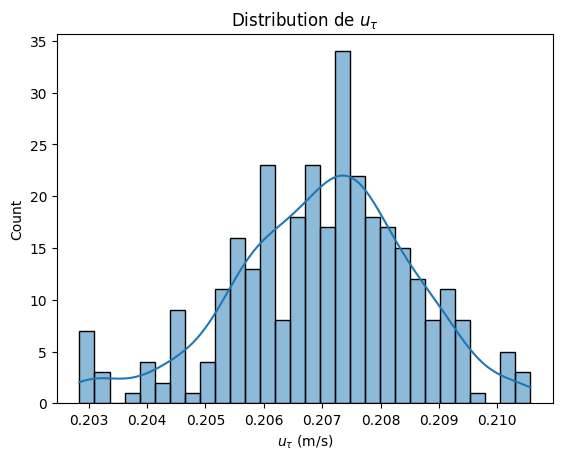

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

m.metadata_df = m.metadata_df.rename(columns={"$u_{\\tau}$" : "u_tau"})
m.metadata_df[["u_tau"]]

plt.figure()

sns.histplot(
    m.metadata_df['u_tau'],
    kde=True,
    bins=30
)

plt.xlabel(r"$u_{\tau}$ (m/s)")
plt.ylabel("Count")
plt.title("Distribution de $u_{\\tau}$")

plt.show()

## Which geographical domain do we focus on?

All available scenarios:

In [24]:
filenames_list = m.metadata_df["NameE"].unique()
filenames_list

array(['AU-Syd-U1_d00', 'AU-Syd-U2_d00', 'AU-Syd-U3_d00',
       'AU-Syd-U4_d00', 'AU-Syd-U5_d00', 'AU-Syd-U6_d00',
       'AU-Syd-U7_d00', 'AU-Mel-U1_d00', 'AU-Mel-U2_d00',
       'AU-Mel-U3_d00', 'AU-Mel-U4_d00', 'AU-Mel-U5_d00',
       'AU-Mel-U6_d00', 'AU-Mel-U7_d00', 'AU-Mel-U8_d00',
       'AU-Mel-U9_d00', 'AU-Mel-U10_d00', 'AU-Mel-U11_d00',
       'AU-Mel-U12_d00', 'AU-Mel-U13_d00', 'AU-Mel-U14_d00',
       'AU-Mel-U15_d00', 'AU-Mel-U16_d00', 'AU-Mel-U17_d00',
       'AU-Mel-U18_d00', 'AU-Mel-U19_d00', 'US-Chi-U1_d00',
       'US-Det-U1_d00', 'US-Det-U2_d00', 'US-Det-U3_d00',
       'US-Det-U4_d00', 'US-Det-U5_d00', 'ES-Bar-U1_d00',
       'CH-Zur-U1_d00', 'CH-Zur-U2_d00', 'CH-Bas-U1_d00',
       'NL-AMS-U1_d00', 'SG-Boo-U1_d00', 'US-Det-U6_d00',
       'US-Det-U7_d00', 'US-Det-U8_d00', 'US-Det-U9_d00',
       'US-Det-U10_d00', 'US-Los-U1_d00', 'CA-Van-U1_d00',
       'CA-Van-U2_d00', 'US-Mia-U1_d00', 'US-Mia-U2_d00',
       'US-Det-U11_d00', 'US-Pho-U1_d00', 'US-Pho-U2_d00',
  

The scenarios used in this workflow:

In [25]:
import scripts.scenario as scenario

reload(scenario)
from scripts.scenario import *

print("List of all scenarios : \n", scenario_list)
print("Number of scenarios : ", len(scenario_list))

List of all scenarios : 
 ['AR-Bue-U2_d00', 'BR-Sao-U2_d00', 'BR-Sao-U3_d00', 'CH-Bas-U1_d00', 'CH-Bas-U1_d00', 'CH-Zur-U2_d00', 'CH-Zur-U2_d90', 'CM-Yao-U1_d00', 'CN-Bei-V1_d00', 'CN-Bei-V1_d15', 'CN-Bei-V1_d30', 'CN-Bei-V1_d45', 'CN-Bei-V1_d60', 'CN-Bei-V1_d75', 'CN-Bei-V1_d90', 'CN-Bei-V1_d105', 'CN-Bei-V1_d120', 'CN-Bei-V1_d135', 'CN-Bei-V1_d150', 'CN-Bei-V1_d165', 'CN-Bei-V1_d180', 'ES-Bar-U1_d00', 'ES-Bar-V1_d00', 'ES-Bar-V1_d90', 'FR-Hau-V1_d00', 'FR-Par-V2_d00', 'FR-Par-V2_d15', 'FR-Par-V2_d30', 'FR-Par-V2_d45', 'FR-Par-V2_d90', 'IT-Rom-V1_d00', 'IT-Rom-V1_d90', 'IT-Rom-U1_d00', 'IT-Rom-U1_d90', 'IT-Rom-V2_d00', 'IT-Rom-V2_d90', 'IT-Rom-U2_d00', 'IT-Rom-U2_d90', 'IT-Rom-V3_d00', 'IT-Rom-V3_d90', 'IT-Rom-U3_d00', 'IT-Rom-U3_d90', 'IT-Rom-V4_d00', 'IT-Rom-V4_d90', 'IT-Rom-U4_d00', 'IT-Rom-U4_d90', 'JP-Tok-V3_d00', 'KO-Yeo-V1_d00', 'KO-Yeo-V1_d15', 'KO-Yeo-V1_d30', 'KO-Yeo-V1_d45', 'KO-Hae-U2_d00', 'KO-Ich-V3_d00', 'KO-Ich-V3_d15', 'KO-Ich-V3_d30', 'KO-Ich-V3_d45', 'KO-Doh-V8_d00'

The georeference workflow retrieve all information on wind data from the name of the scenario i.e. `filename`. In the processing chain, the 3D wind data stored in `.nc` files are removed so as not to overload the storage space. 

It is strongly recommended that you keep a backup copy of the NetCDF files on a storage device outside the project environment.

Retrieve nc file code with filename :

In [26]:
# filename = scenario_list[0]
filename = "FR-Hau-V1_d00"
print(filename)
nc_code = m.metadata_df["NameI"][m.metadata_df["NameE"] == filename].iloc[0]
if pd.isna(nc_code) or not str(nc_code).strip():
    print(f"NameI (nc file code) is empty: {nc_code}.")
nc_file = f"{nc_code}_data.nc"
nc_path = os.path.join(path_3D, nc_file)
if os.path.exists(nc_path) :
    print(f"{nc_file} found at: {nc_path}")
else :
    print(f"File not found at: {nc_path}")
    print(f"The file may already have been deleted and converted to raster layers.")

FR-Hau-V1_d00
File not found at: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Projet_git/Data/Copie_UrbanTALES/3Dwind/A8_data.nc
The file may already have been deleted and converted to raster layers.


... or retrieve filename and nc file code with country :

In [30]:
country = "France"

scenario_list = m.retrieve_filenames(country=country)
# nc_list = fct.list_nc_files(path_3d_folder=path_3D)
print(scenario_list)

[('A8', 'FR-Hau-V1_d00'), ('A9', 'FR-Par-V2_d00'), ('15A9', 'FR-Par-V2_d15'), ('30A9', 'FR-Par-V2_d30'), ('45A9', 'FR-Par-V2_d45'), ('90A9', 'FR-Par-V2_d90')]


Retrieve all wind information on this scenario : 

In [32]:
wind_dict = m.retrieve_wind_info(filename)
epsg = wind_dict["epsg"].to_epsg()
wind_dict

{'filename_e': 'FR-Hau-V1_d00',
 'filename_i': 'A8',
 'wind_dir': '0',
 'lon': 2.2757388888888888,
 'lat': 48.829097222222224,
 'city': 'Hauts-de-Seine',
 'localisation': 'Hauts-de-Seine',
 'epsg': <Projected CRS: EPSG:32631>
 Name: WGS 84 / UTM zone 31N
 Axis Info [cartesian]:
 - E[east]: Easting (metre)
 - N[north]: Northing (metre)
 Area of Use:
 - name: Between 0°E and 6°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Andorra. Belgium. Benin. Burkina Faso. Denmark - North Sea. France. Germany - North Sea. Ghana. Luxembourg. Mali. Netherlands. Niger. Nigeria. Norway. Spain. Togo. United Kingdom (UK) - North Sea.
 - bounds: (0.0, 0.0, 6.0, 84.0)
 Coordinate Operation:
 - name: UTM zone 31N
 - method: Transverse Mercator
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich}

Copy the following coordinates in OSM Nominatim:

In [33]:
print(wind_dict.get("lat"), ",", wind_dict.get("lon"))

48.829097222222224 , 2.2757388888888888


The OSM Nominatim service will allow you to visualize this scenario. 

## Load nc file

In this step, the NetCDF file is retrieved, transformed into 100 rasters (one per height layer). The `.nc` file is deleted after this step. It is strongly recommended that you keep a backup copy of the NetCDF files on a storage device outside the project environment.

In [39]:
nc = NetCdf(
    filename_e=filename, metadata=m, path_3d_folder=PATH_3D, georef_input=GEOREF_INPUT
)

nc.nc_xr
nc.process_nc(overwrite=False)

⚠️ NetCDF file not found: %s /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/UrbanTALES/3Dwind/A8_data.nc
All rasters (.tif files) exist, no need to process NetCDF file.
Files are stored at :  /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_input/FR-Hau-V1_d00
⚠️ NetCDF file not found: %s /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/UrbanTALES/3Dwind/None_data.nc
Nc file already deleted or not found, 
If any doubt, please check the data stored in SSD support.


## Topo file to raster

Open and process to rasterize the topo file used in UrbanTALES associated with the `filename_e`.

To begin: add name_topo in metada. This could be filename_e or another name, please check the associated folder to confirm.

In [36]:
# Add name_topo of the domain

df = m.metadata_df

# Finding line which NameE begins with filename
match_df = df[df["NameE"].astype(str) == str(filename)]
# match_df["angle_domain"] = pd.NA

if not match_df.empty:
    # We retrieve first correspondence
    row = match_df.iloc[0]
    if pd.notna(row.get("name_topo")):
        name_topo = str(row["name_topo"])
        print(f"Topo file name retrieved from metadata : {name_topo}")
    else:
        print("Enter the topo name manually (name_topo empty in metadata)")
        # Determine the name of topo file from associated folder
        name_topo = "new_name_topo" # <--- change this entry
        m.metadata_df = m.add_name_topo_to_metadata(name_topo=name_topo, filename_e=filename)

else:
    print("Enter the name of topo file manually (no correspondance in NameE)")

Topo file name retrieved from metadata : FR-PA-V1_d00


If need to change name_topo :

In [ ]:
# df = m.metadata_df
# # please check the Data/UrbanTALES/topo folder to find the correct topo name
# name_topo_modified = "new_name_topo" # <--- change this entry
# match_df = df[df["NameE"].astype(str) == str(filename)]
# if not match_df.empty:
#     row = match_df.iloc[0]
#     m.metadata_df = m.add_name_topo_to_metadata(
#         name_topo=name_topo_modified, filename_e=filename)

In [40]:
topo_test = TopoRaster(
    filename_e=filename,
    georef_input=GEOREF_INPUT,
    georef_output=GEOREF_OUTPUT,
    path_data=DATA_DIR,
    m=m,
)

# topo_test.dataset
# topo_test.close

[INFO] Topo file found in location: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/UrbanTALES/topo/FR-PA-V1_d00/FR-PA-V1_d00_topo
✅ Topo raster already exists at /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/Extracting_buildings/FR-Hau-V1_d00/layer_topo.tif.
✅ TopoRaster successfully initialized for FR-Hau-V1_d00.


## Georeference operation

For georeference operations, we did not compute any classes and choose to use functions instead.

Steps to prepare for georeferencing: 

- Open a QGIS project 
- Set the project's EPSG code to the EPSG code found in the metadata (`epsg` object)
- Load an OSM layer into the QGIS project
- Using the domain's location and the scenario visualization in Nominatim, locate the scenario visually on the OSM layer in the QGIS project
- Open `Layer > Georeference` and load the first wind raster (`wind_layer_0.25.tif`)
- Place at least 4 points on this raster by matching them with the domain identified in QGIS
- Apply a polynomial transformation (more details given in corresponding paper)
- After this transformation, generate a GDAL script by selecting in the Georeferencer window `File > Generate a GDAL script` 
- Save this script in `Georef_input > filename > gdal_command.txt`.

Run the following cell to know if you have to process manually or if the gdal command already exists:

In [42]:
import scripts.functions as fct

fct.find_gcp(filename=filename, georef_input=georef_input)

File 'gdal_command.txt' already exists.


Then launch the georeferencement:

In [43]:
import scripts.functions as fct

reload(fct)

groovy_georef_path = os.path.join(
    PROJECT_ROOT,
    "groovy",
    "WindDataGDALCommands.groovy",
)

fct.georeferencement(
    filename_e=filename,
    topo=topo_test,
    georef_input=GEOREF_INPUT,
    georef_output=GEOREF_OUTPUT,
    path_data=DATA_DIR,
    groovy_path=groovy_georef_path,
)

Prepare tmp folder like presented in 0_expl_tmp.
[INFO] Topo file found in location: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/UrbanTALES/topo/FR-PA-V1_d00/FR-PA-V1_d00_topo
Copying topo file...
Copying wind files...
Copying groovy script...
✅ All files have been copied to /tmp/lenaig.
Standard output : echo A set of GDAL commands to transform the wind images in the good projection


echo Step 1 : Extract the polygon as a geometry
echo replace NaN values to -9999
gdal_calc.py -A /tmp/lenaig/wind_layer_0.25.tif --outfile=/tmp/lenaig/results/wind_layer_0.25_nan.tif --calc='numpy.nan_to_num(A, nan=-9999)'
echo start translating... /tmp/lenaig/results/wind_layer_0.25_georef.tif
gdal_translate -of GTiff -gcp 30.206 551.241 446857.222 5408683.655 -gcp 504.774 552.818 447193.487 5409014.451 -gcp 542.874 79.07 447553.772 5408703.921 -gcp 156.992 229.265 447172.658 5408540.881 -gcp 296.105 407.131 447146.522 5408765.576 /tmp/lenaig/results/win

'/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_output/FR-Hau-V1_d00'

The georeferenced topo file is loaded with another class

✅ TopoRasterGeoref successfully initialized for FR-Hau-V1_d00.
vmin = 0.0 vmax = 27.0


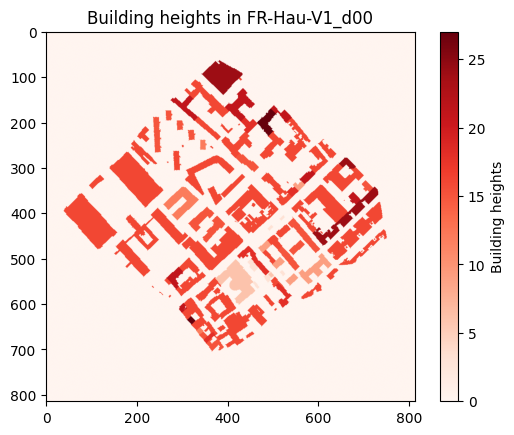

✅ GeoJSON file saved: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_output/FR-Hau-V1_d00/topo.geojson


In [44]:
topo_georef = TopoRasterGeoref(filename_e=filename, georef_output=GEOREF_OUTPUT)
topo_georef.to_geojson(viz=True)  # save into geojson

## Adding angle value

The angle value is directly retrieved from metadata.

In [50]:
df = m.metadata_df
angle = df[df["NameE"] == filename]["angle_domain"].iloc[0]
print("Angle : ", angle)

Angle :  44.368


If the angle value is not stored in the metadata, you can add it manually. To do that, measure the angle between X axis of georeferenced wind layer and longitudinal axis on QGIS and store it in metadata with the following command.

In [51]:
# Add angle value of the domain
# metadata = m.metadata_df
df = m.metadata_df
# filename = "IT-Rom-V4_d00"
# Finding line which NameE begins with filename
match_df = df[df["NameE"].astype(str) == str(filename)]
# match_df["angle_domain"] = pd.NA

if not match_df.empty:
    # We retrieve first correspondence
    row = match_df.iloc[0]
    if pd.notna(row.get("angle_domain")):
        angle = float(row["angle_domain"])
        print(f"Angle retrieved from metadata : {angle}")
    else:
        print("Enter the angle value manually (angle_domain empty in metadata)")
        # Determine the angle value at hand with QGIS
        # angle = 34 # <--- enter here the angle value you retrieved as integer
        # m.metadata_df = m.add_angle_to_metadata(angle=angle, filename_e=filename)

else:
    print("Enter the angle value manually (no match in NameE).")

Angle retrieved from metadata : 44.368


If you need to change angle value, you can de-indent and execute the following command :

In [52]:
# df = m.metadata_df
# angle_modified = 56.110 # <--- enter here the new angle value
# match_df = df[df["NameE"].astype(str) == str(filename)]
# if not match_df.empty:
#     row = match_df.iloc[0]
#     m.metadata_df = m.add_angle_to_metadata(
#         angle=angle_modified, filename_e=filename)

## Base grid
Construction of the base grid on the scenario.

grid_path:  /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_output/FR-Hau-V1_d00/grid_square_fixed_res_50m_center.geojson
✅ Grid successfully loaded.


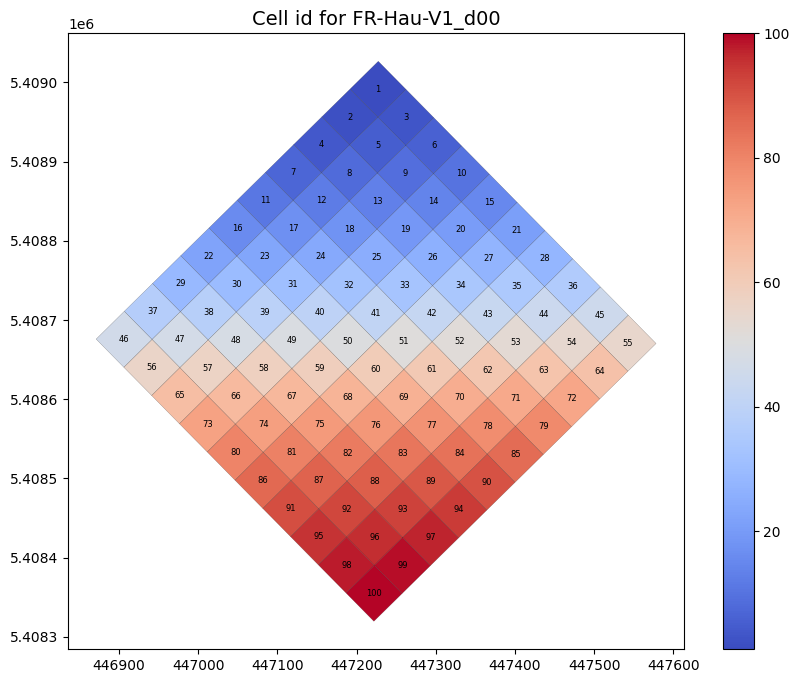

In [54]:
base_grid = Grid(
    georef_output=GEOREF_OUTPUT,
    path_data=DATA_DIR,
    filename_e=filename,
    buffer=20,
    target_resolution=50,
    epsg=epsg,
)

base_grid.gdf_grid.head()
base_grid.epsg
a = base_grid._create_cell_id(base_grid.gdf_grid)

In [55]:
base_grid.epsg

32631

## Wind grid

Creation of the wind grid from base grid. The wind variables are computed on this grid.

In [56]:
wind_grid_test = WindGrid(base_grid, m)
wind_grid_test.gdf_wind_grid.head()

Loading wind grid...
Wind grid loaded!


,x,y,cell_id,mean_w,wind_mean_lon,wind_mean_lat,speed_mean,std_w,wind_std_lon,wind_std_lat,...,q75_norm_speed,q10_norm_speed,q90_norm_speed,z,WD_deg,WD_rad,init_speed,init_lon,init_lat,geometry
0,447227.130334,5.408991e+06,1,0.004928,-0.025423,-0.005427,0.025995,0.020979,0.203181,0.012311,...,0.255525,0.090513,0.299213,0.25,134.368,2.345164,1.0,0.714863,0.699264,"POLYGON ((447262.485 5408991.043, 447227.409 5..."
1,447191.497711,5.408956e+06,2,-0.007568,-0.351082,-0.351852,0.497050,0.059278,0.362684,0.051751,...,0.766774,0.180872,0.914461,0.25,134.368,2.345164,1.0,0.714863,0.699264,"POLYGON ((447226.852 5408955.968, 447191.776 5..."
2,447262.206197,5.408956e+06,3,-0.000237,-0.142277,0.281454,0.315372,0.030578,0.317885,-0.041085,...,0.563737,0.111219,0.679801,0.25,134.368,2.345164,1.0,0.714863,0.699264,"POLYGON ((447297.56 5408955.411, 447262.485 54..."
3,447155.865088,5.408921e+06,4,0.001904,-0.089038,-0.183094,0.203595,0.018536,0.179142,0.062629,...,0.361051,0.059778,0.427010,0.25,134.368,2.345164,1.0,0.714863,0.699264,"POLYGON ((447191.219 5408920.892, 447156.143 5..."
4,447226.573574,5.408921e+06,5,0.002766,-0.237304,0.248475,0.343588,0.043742,0.396299,0.022493,...,0.637880,0.140085,0.864329,0.25,134.368,2.345164,1.0,0.714863,0.699264,"POLYGON ((447261.928 5408920.335, 447226.852 5..."


## Geo grid
Creation of the geo grid from base grid

Begin Extract Buildings....
Standard output : 
Potential errors : Caught: java.io.FileNotFoundException: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/extractBuilding.groovy (/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/extractBuilding.groovy)
java.io.FileNotFoundException: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/extractBuilding.groovy (/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/extractBuilding.groovy)

Output code : 1
End Extract buildings
File found: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_output/FR-Hau-V1_d00/osm_48.82561_2.2761002_48.831974_2.2857344/building.fgb


<Figure size 640x480 with 0 Axes>

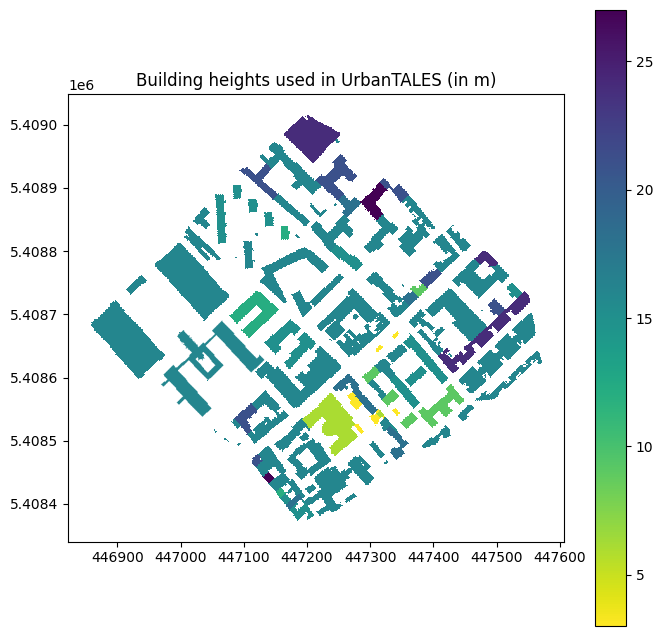

CRS of OSM file:  EPSG:32631
CRS of topo file:  EPSG:32631


<Figure size 640x480 with 0 Axes>

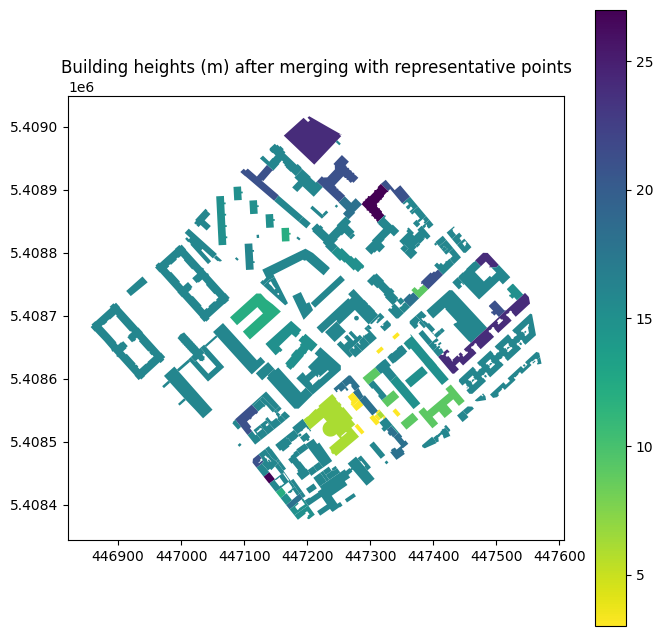

→ 258 buildings without height after 'within'. Attempt with 'intersects'.
Heights attributed to 239 / 460 buildings.


<Figure size 640x480 with 0 Axes>

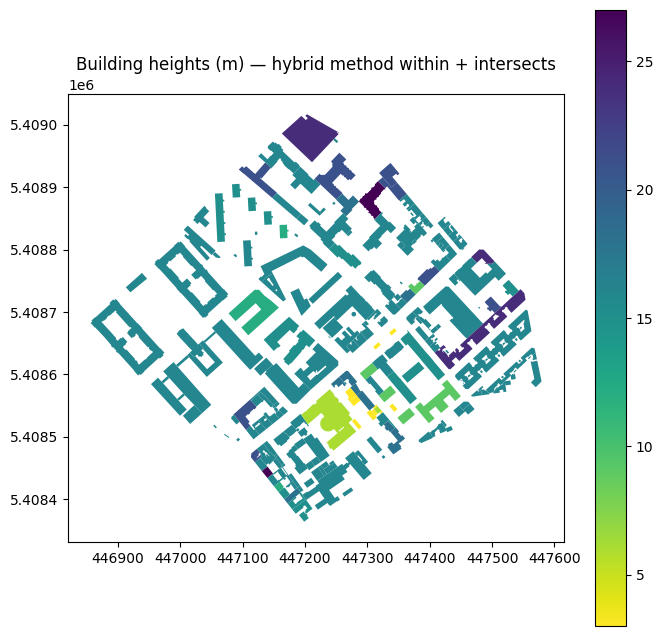

Before cleaning : 460 buildings
After cleaning : 239 buildings


/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Figure size 640x480 with 0 Axes>

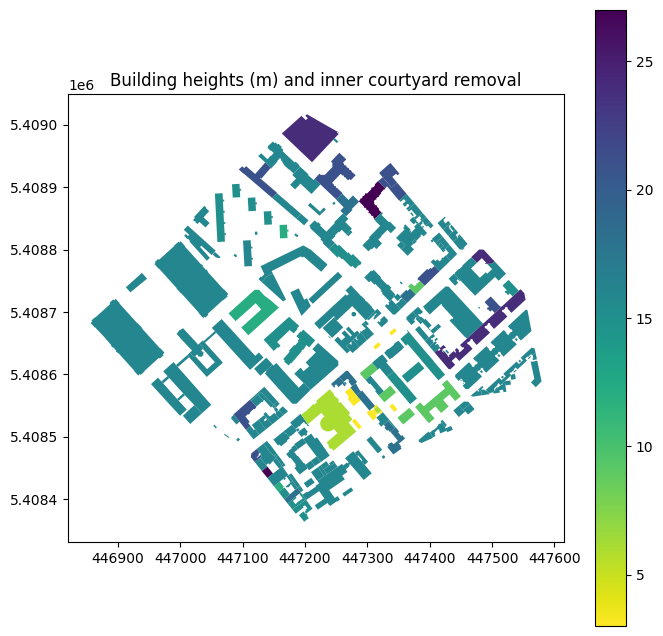

File stored here: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_output/FR-Hau-V1_d00/buildings_with_height.geojson
Begin extract geo from grid ...
Standard output : 
Potential errors : Caught: java.io.FileNotFoundException: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/geoClimateIndicators.groovy (/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/geoClimateIndicators.groovy)
java.io.FileNotFoundException: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/geoClimateIndicators.groovy (/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/Groovy/geoClimateIndicators.groovy)

Output code : 1
End extract geo !


In [57]:
groovy_path_eb = os.path.join(PROJECT_ROOT, "Groovy", "extractBuilding.groovy")
groovy_path_geo = os.path.join(
    PROJECT_ROOT, "Groovy", "geoClimateIndicators.groovy"
)

geo_grid_test = GeoGrid(
    base_grid, groovy_path_eb=groovy_path_eb, groovy_path_geo=groovy_path_geo
)

Check if epsg codes are equals :

In [58]:
print(wind_grid_test.grid.epsg)
print(geo_grid_test.grid.epsg)

32631
32631


Insight on grids:

In [59]:
wind_grid_test.gdf_wind_grid.columns
geo_grid_test.gdf_geo_grid.head()
geo_grid_test.gdf_geo_grid.columns

Index(['CELL_ID', 'BUILDING_FRACTION', 'UNDEFINED_FRACTION',
       'AVG_HEIGHT_ROOF', 'STD_HEIGHT_ROOF',
       'GEOM_AVG_HEIGHT_ROOF', 'BUILDING_NUMBER_DENSITY',
       'BLOCK_NUMBER_DENSITY', 'BUILDING_DIRECTION_EQUALITY',
       'BUILDING_DIRECTION_UNIQUENESS',
       'MAIN_BUILDING_DIRECTION',
       'AVG_HEIGHT_ROOF_AREA_WEIGHTED',
       'STD_HEIGHT_ROOF_AREA_WEIGHTED',
       'FREE_EXTERNAL_FACADE_DENSITY', 'ASPECT_RATIO',
       'STREET_WIDTH', 'BUILDING_SURFACE_DENSITY', 'SVF',
       'PROJECTED_FACADE_DENSITY_DIR_D0_30',
       'PROJECTED_FACADE_DENSITY_DIR_D30_60',
       'PROJECTED_FACADE_DENSITY_DIR_D60_90',
       'PROJECTED_FACADE_DENSITY_DIR_D90_120',
       'PROJECTED_FACADE_DENSITY_DIR_D120_150',
       'PROJECTED_FACADE_DENSITY_DIR_D150_180',
       'EFFECTIVE_TERRAIN_ROUGHNESS_LENGTH',
       'EFFECTIVE_TERRAIN_ROUGHNESS_CLASS', 'geometry'],
      dtype='object')

## Final grid

The final grid is generated:

In [60]:
final_grid_test = FinalGrid(wind_grid=wind_grid_test, geo_grid=geo_grid_test)
# table = final_grid_test.final_grid

✅ Set GEOMETRY as active geometry for gdf1
✅ Set GEOMETRY as active geometry for gdf2
✅ Identical geometries detected: kept only one geometry column.
Saved in: /home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/Data/GeoReference/Georef_output/FR-Hau-V1_d00/final_50m.geojson


In [61]:
final_grid_test.final_grid.head()

,X,Y,CELL_ID,MEAN_W,WIND_MEAN_LON,WIND_MEAN_LAT,SPEED_MEAN,STD_W,WIND_STD_LON,WIND_STD_LAT,...,SVF,PROJECTED_FACADE_DENSITY_DIR_D0_30,PROJECTED_FACADE_DENSITY_DIR_D30_60,PROJECTED_FACADE_DENSITY_DIR_D60_90,PROJECTED_FACADE_DENSITY_DIR_D90_120,PROJECTED_FACADE_DENSITY_DIR_D120_150,PROJECTED_FACADE_DENSITY_DIR_D150_180,EFFECTIVE_TERRAIN_ROUGHNESS_LENGTH,EFFECTIVE_TERRAIN_ROUGHNESS_CLASS,GEOMETRY
0,447227.130334,5.408991e+06,1,0.004928,-0.025423,-0.005427,0.025995,0.020979,0.203181,0.012311,...,0.609345,0.053546,0.009329,0.006974,0.002750,0.031632,0.089348,0.632220,6,"POLYGON ((447262.485 5408991.043, 447227.409 5..."
1,447191.497711,5.408956e+06,2,-0.007568,-0.351082,-0.351852,0.497050,0.059278,0.362684,0.051751,...,0.599756,0.123215,0.120031,0.103785,0.059745,0.004275,0.033648,1.357477,7,"POLYGON ((447226.852 5408955.968, 447191.776 5..."
2,447262.206197,5.408956e+06,3,-0.000237,-0.142277,0.281454,0.315372,0.030578,0.317885,-0.041085,...,0.706579,0.016306,0.012110,0.023226,0.028120,0.026845,0.042676,0.456069,6,"POLYGON ((447297.56 5408955.411, 447262.485 54..."
3,447155.865088,5.408921e+06,4,0.001904,-0.089038,-0.183094,0.203595,0.018536,0.179142,0.062629,...,0.645168,0.071261,0.053136,0.049406,0.032438,0.011806,0.034664,0.721302,6,"POLYGON ((447191.219 5408920.892, 447156.143 5..."
4,447226.573574,5.408921e+06,5,0.002766,-0.237304,0.248475,0.343588,0.043742,0.396299,0.022493,...,0.507991,0.052057,0.029962,0.047542,0.054824,0.050887,0.060883,0.989807,7,"POLYGON ((447261.928 5408920.335, 447226.852 5..."


In [62]:
final_grid_test.final_grid.columns

Index(['X', 'Y', 'CELL_ID', 'MEAN_W', 'WIND_MEAN_LON',
       'WIND_MEAN_LAT', 'SPEED_MEAN', 'STD_W', 'WIND_STD_LON',
       'WIND_STD_LAT', 'SPEED_STD', 'Q25_W', 'WIND_Q25_LON',
       'WIND_Q25_LAT', 'SPEED_Q25', 'Q75_W', 'WIND_Q75_LON',
       'WIND_Q75_LAT', 'SPEED_Q75', 'MIN_W', 'WIND_MIN_LON',
       'WIND_MIN_LAT', 'SPEED_MIN', 'MAX_W', 'WIND_MAX_LON',
       'WIND_MAX_LAT', 'SPEED_MAX', 'ANGLE_WIND_DEG',
       'ANGLE_WIND_RAD', 'MEAN_NORM_SPEED',
       'MEDIAN_NORM_SPEED', 'STD_NORM_SPEED', 'Q25_NORM_SPEED',
       'Q75_NORM_SPEED', 'Q10_NORM_SPEED', 'Q90_NORM_SPEED',
       'Z', 'WD_DEG', 'WD_RAD', 'INIT_SPEED', 'INIT_LON',
       'INIT_LAT', 'BUILDING_FRACTION', 'UNDEFINED_FRACTION',
       'AVG_HEIGHT_ROOF', 'STD_HEIGHT_ROOF',
       'GEOM_AVG_HEIGHT_ROOF', 'BUILDING_NUMBER_DENSITY',
       'BLOCK_NUMBER_DENSITY', 'BUILDING_DIRECTION_EQUALITY',
       'BUILDING_DIRECTION_UNIQUENESS',
       'MAIN_BUILDING_DIRECTION',
       'AVG_HEIGHT_ROOF_AREA_WEIGHTED',
       'STD_HEIG

End of the workflow execution.

## Visualisation of wind 

In [66]:
reload(fct)

<module 'scripts.functions' from '/home/llegrogn/Documents/These_Lenaig_perso/Lenaig_Le_Grognec/4.Coding/Georef_UrbanTALES/georef-UrbanTALES/scripts/functions.py'>

<positron-console-cell-67>:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


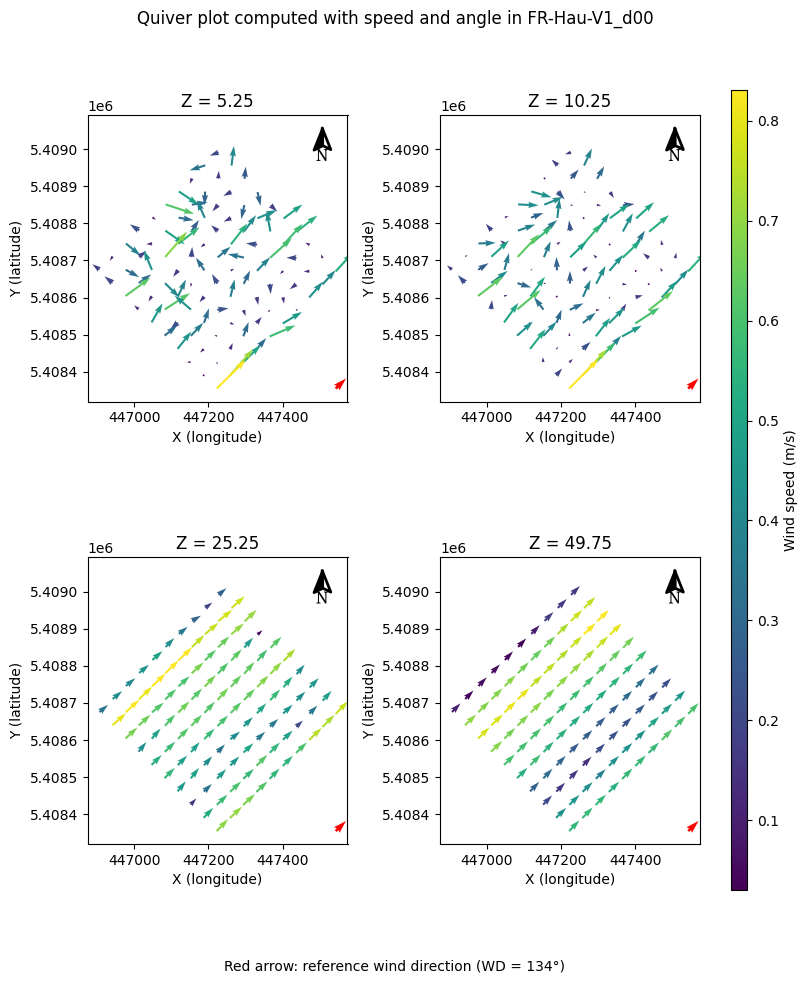

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from geo_northarrow import add_north_arrow

gdf = fct.open_final_gdf(filename, georef_output=GEOREF_OUTPUT, res_cell=50)
name_df = filename
cmap = "viridis"

Z = sorted(gdf["Z"].unique())
z_list = [Z[10], Z[20], Z[50], Z[99]]

x0 = gdf["X"].max()
y0 = gdf["Y"].min()
ymax = gdf["Y"].max() - 3

WD = float(gdf["WD_DEG"].iloc[0])

fig, axes = plt.subplots(2, 2, figsize=(8, 10))
axes = axes.flatten()
quiv_for_colorbar = None
for i, z in enumerate(z_list):
    df_z = gdf[gdf["Z"] == z]
    Q = axes[i].quiver(
        df_z["X"].values,
        df_z["Y"].values,
        df_z["WIND_MEAN_LON"],
        df_z["WIND_MEAN_LAT"],
        df_z["SPEED_MEAN"],
        angles="xy",
        scale_units="xy",
        scale=None,
        cmap=cmap,
        width=0.008,  
    )
    if quiv_for_colorbar is None:
        quiv_for_colorbar = Q
    axes[i].quiver(
        x0,
        y0,
        df_z["INIT_LON"].iloc[0],
        df_z["INIT_LAT"].iloc[0],
        color="red",
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.01,  
        zorder=15,
    )
    add_north_arrow(
        axes[i],
        scale=0.75,
        xlim_pos=0.9025,
        ylim_pos=0.965,
        color="#000",
        text_scaler=4,
        text_yT=-1.25,
    )
    axes[i].set_title(f"Z = {z}")
    axes[i].set_xlabel("X (longitude)")
    axes[i].set_ylabel("Y (latitude)")

for j in range(len(z_list), len(axes)):
    fig.delaxes(axes[j])

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(quiv_for_colorbar, cax=cbar_ax)
cbar.set_label("Wind speed (m/s)")
fig.text(
    0.5,
    0.02,
    f"Red arrow: reference wind direction (WD = {WD:.0f}°)",
    ha="center",
    fontsize=10,
    color="black",
)
plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])
plt.suptitle(f"Quiver plot computed with speed and angle in {name_df}", y=0.98)
plt.show()

We can also plot wind speed and building geometries:

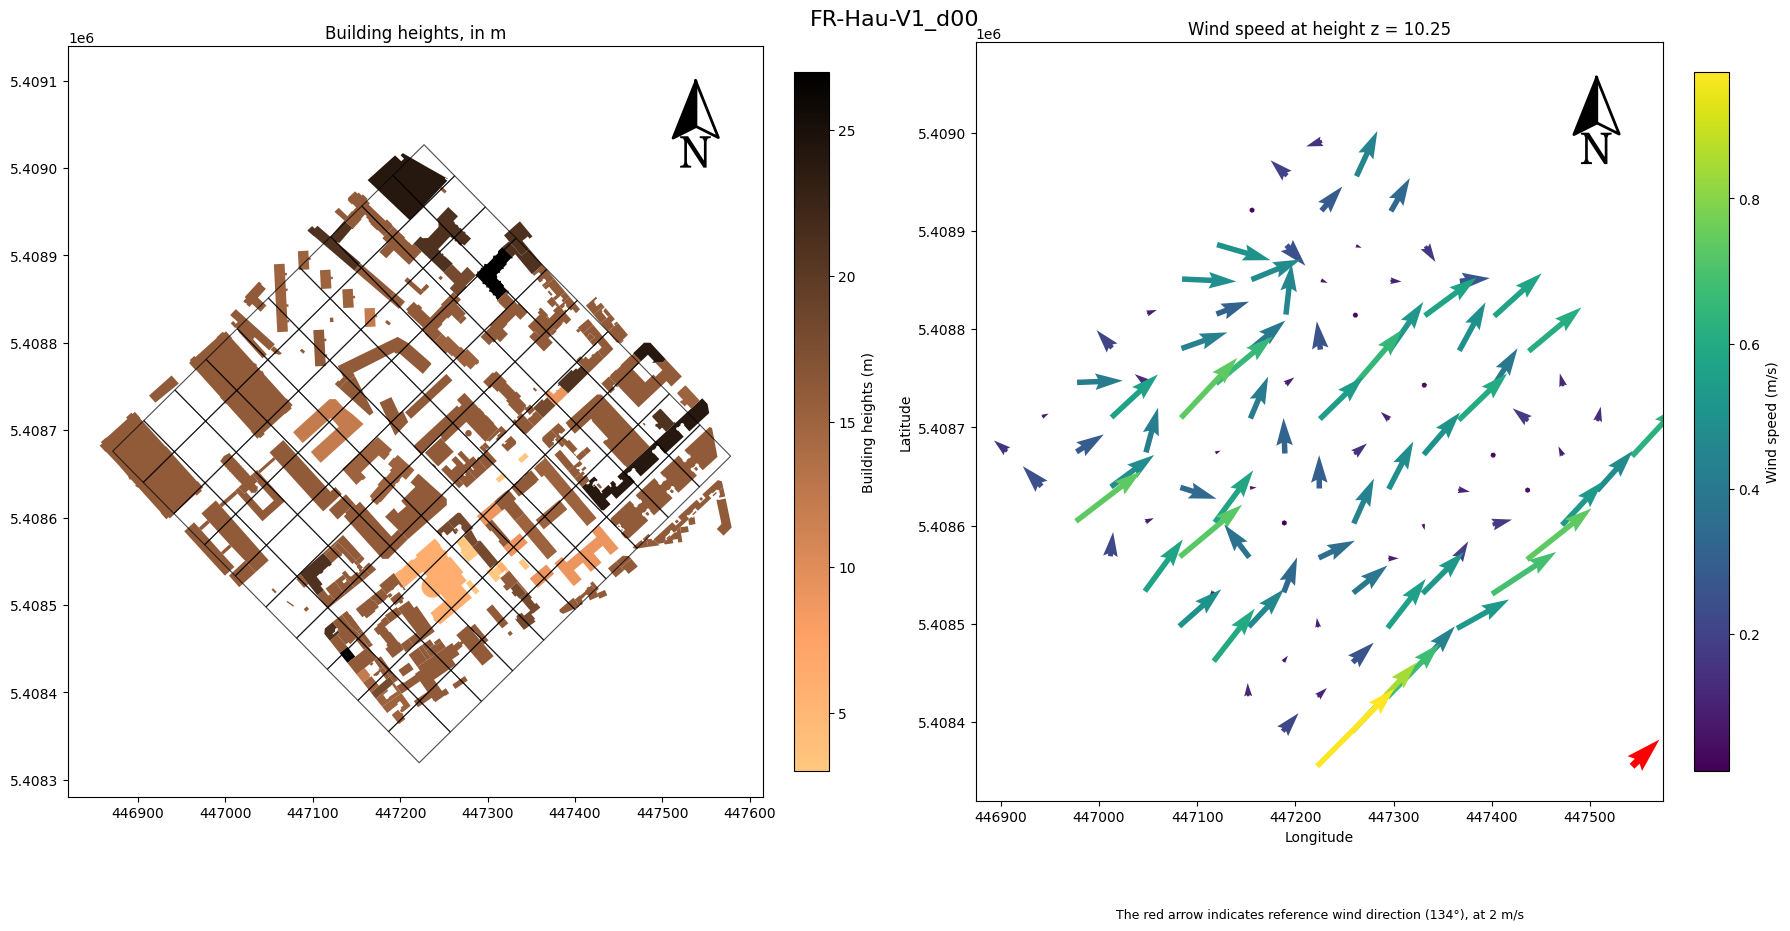

In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl

gdf = fct.open_final_gdf(filename, georef_output=GEOREF_OUTPUT, res_cell=50)
name_df = filename
cmap = "viridis"
var_wind = "SPEED"
z_value = 10.25
unique_cells = sorted(gdf["CELL_ID"].unique())

fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(1, 2)
ax_height = fig.add_subplot(gs[0, 0])  
ax_quiver = fig.add_subplot(gs[0, 1]) 

gdf_height = gpd.read_file(
    os.path.join(georef_output, name_df, "buildings_with_height.geojson")
)
grid = gpd.read_file(
    os.path.join(
        georef_output, name_df, "grid_square_fixed_res_50m_center.geojson"
    )
)
gdf_height.plot(
    ax=ax_height,
    column="height",
    cmap="copper_r",
    legend=False,
    figsize=(8, 8),
)
grid.boundary.plot(
    ax=ax_height,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.7,
)
add_north_arrow(
    ax_height,
    scale=0.75,
    xlim_pos=0.9025,
    ylim_pos=0.965,
    color="#000",
    text_scaler=4,
    text_yT=-1.25,
)
norm = mpl.colors.Normalize(
    vmin=gdf_height["height"].min(),
    vmax=gdf_height["height"].max()
)
sm = mpl.cm.ScalarMappable(cmap="copper_r", norm=norm)
sm.set_array([])

cbar_height = fig.colorbar(sm, ax=ax_height, fraction=0.046, pad=0.04)
cbar_height.set_label("Building heights (m)")
ax_height.set_title("Building heights, in m")

gdf_z = gdf[gdf["Z"]==z_value]
X = gdf_z["X"].values
Y = gdf_z["Y"].values
U = gdf_z["WIND_MEAN_LON"]
V = gdf_z["WIND_MEAN_LAT"]
C = gdf_z["SPEED_MEAN"] # color
Q = ax_quiver.quiver(
    X, Y, U, V,
    C,
    angles="xy",
    scale_units="xy",
    scale=None,
    cmap="viridis",
    width=0.008,        
)
ax_quiver.quiver(
    x0,
    y0,
    gdf_z["INIT_LON"].iloc[0],
    gdf_z["INIT_LAT"].iloc[0],
    color="red",
    angles="xy",
    scale_units="xy",
    scale=None,
    width=0.01,  
    zorder=15,
)
add_north_arrow(
    ax_quiver,
    scale=0.75,
    xlim_pos=0.9025,
    ylim_pos=0.965,
    color="#000",
    text_scaler=4,
    text_yT=-1.25,
)
ax_quiver.set_aspect('equal')
ax_quiver.set_title(f"Wind speed at height z = {z_value}") # colored by speed
ax_quiver.set_xlabel("Longitude")
ax_quiver.set_ylabel("Latitude")
cbar = plt.colorbar(Q, ax=ax_quiver, fraction=0.046, pad=0.04)
cbar.set_label("Wind speed (m/s)")
ax_quiver.text(
    0.5, -0.15,
    f"The red arrow indicates reference wind direction ({WD:.0f}°), at 2 m/s",
    ha="center",
    va="center",
    transform=ax_quiver.transAxes,
    fontsize=9,
)
plt.suptitle(f"{name_df}", fontsize=16)
plt.tight_layout()
plt.show()